In [ ]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.strategies import DDPStrategy
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from dataprocess_dgl import Mesh2a1vDGL, create_dataloaders, collate_cc_as_node, collate_cc_as_edge, collate_graphomer, collate_cc_as_edge_pe
from dataprocess_pyg import Mesh2a1vPYG
from utils import plot_acc_w_segment
from ogb.graphproppred import Evaluator
from model import GNNDelay, DeepGCNDelay, GraphomerDelay,  SiGTDelay, GraphGPSDelay, SGFormerDelay
import pickle

/home/csgrad/yhu/miniconda3/envs/crosstalk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_name = 'GraphGPS'  # 'NormGNN', 'DeepGCN', 'Graphomer', 'SGFormer', 'GraphGPS', 'SiGT'
task = 'delay'
mode = 'segment'  # 'segment' or 'sink'
vic_only = False # Whether to use only VIC nodes for training and evaluation. If False, all nodes are used.
raw_data = f'./{task}'
exp_name = f'{mode}-2A1V-{model_name}'
batch_size=256
num_epochs = 60

if model_name == 'NormGNN':
    root = f'./{task}_dataset/DGL/{mode}/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = GNNDelay(in_ch=1, out_ch=1, hidden_channels=128, batch_size=batch_size, gnn_type='gatedgraph', lr=0.002)
    
elif model_name == 'DeepGCN':
    root = f'./{task}_dataset/DGL/{mode}/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    os.makedirs(root, exist_ok=True)
    model = DeepGCNDelay(in_ch=1,out_ch=1,hidden_channels=64,conv_layer_num=20,batch_size=batch_size,lr=0.001,dropout=0.1,block_type='res+', vic_only=vic_only)
    
elif model_name == 'Graphomer':
    root = f'./{task}_dataset/DGL/segment/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vDGL(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing='segment', cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'DGL', collate_fn=collate_graphomer)
    total_updates = 33000 * num_epochs / batch_size
    warmup_updates = total_updates * 0.16
    model = GraphomerDelay(total_updates=total_updates, warmup_updates=warmup_updates, lr=1e-4, weight_decay=0.0, eps=1e-8, batch_size=batch_size, mode=mode, vic_only=vic_only)

elif model_name == "SGFormer":
    root = f'./{task}_dataset/DGL/{mode}/left_pe_16'
    os.makedirs(root, exist_ok=True)
    cfg = {
        'posenc_RWSE': {
            'enable': True,
            'kernel': {
                'times_func': range(1, 17),
                'times': list(range(1, 17)),  
            },
            'model': 'Linear',
            'dim_pe': 16,
            'raw_norm_type': 'BatchNorm'
        }
    }
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge', pe=True, pe_type=["RWSE"], cfg=cfg)
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = SGFormerDelay(channels=64, pe_dim=16, num_layers=4, batchsize=batch_size, vic_only=vic_only)

elif model_name == 'GraphGPS':
    root = f'./{task}_dataset/DGL/{mode}/left_EqlapPE8+RWSE16'
    os.makedirs(root, exist_ok=True)
    cfg = {
        'posenc_RWSE': {
            'enable': True,
            'kernel': {
                'times_func': range(1, 17),
                'times': list(range(1, 17)),  
            },
            'model': 'Linear',
            'dim_pe': 16,
            'raw_norm_type': 'BatchNorm'
        },
        "posenc_EquivStableLapPE": {
            "enable": True,
            "eigen": {
                "laplacian_norm": "none",
                "eigvec_norm": "L2",
                "max_freqs": 8
            },
            "raw_norm_type": "none"
        }
    }
    dataset = Mesh2a1vPYG(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing=mode, cc_pattern='as_edge', pe=True, pe_type=["EquivStableLapPE", "RWSE"], cfg=cfg)
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'PYG')
    model = GraphGPSDelay(channels=64, input_dim=24, pe_dim=8, num_layers=10, attn_type='multihead', batchsize=batch_size, vic_only=vic_only)
    
elif model_name == 'SiGT':
    root = f'./{task}_dataset/DGL/segment/left'
    os.makedirs(root, exist_ok=True)
    dataset = Mesh2a1vDGL(root=root, raw_data=raw_data, directed=False, accumulation=False, task=task, timing='segment', cc_pattern='as_edge')
    train_loader, valid_loader, test_loader = create_dataloaders(dataset, batch_size, 'DGL', collate_fn=collate_cc_as_edge)
    total_updates = 33000 * num_epochs / batch_size
    warmup_updates = total_updates * 0.16
    model = SiGTDelay(node_encoding='sgnn', total_updates=total_updates, warmup_updates=warmup_updates, lr=4e-4, weight_decay=0.0, eps=1e-8, batch_size=batch_size, mode=mode, vic_only=vic_only)

/home/csgrad/yhu/projs/crosstalk/dataprocess_pyg.py:279: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.slices = torch.load(self.processed_paths[0])


200200


/home/csgrad/yhu/miniconda3/envs/crosstalk/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import re


def plot_acc_w_segment(data_dict, img_pth):
    for key, value in data_dict.items():
        if math.isnan(sum(value)) or len(value) == 0:  # Check for NaN or empty list
            data_dict[key] = 0
        else:
            data_dict[key] = sum(value) / len(value)
        if data_dict[key] < 0:
            data_dict[key] = 0
    sorted_keys = sorted(data_dict.keys())
    x = sorted_keys
    y = [data_dict[k] for k in x]

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker='o', linestyle='-') 
    
    for x_val, y_val in zip(x, y):
        plt.text(x_val, y_val, f"{y_val}", 
                 ha='center', va='bottom', 
                 fontsize=9, color='black')  

    plt.xlabel('Number of Segments')
    plt.ylabel('Predict Acc %')
    plt.grid(True)
    plt.savefig(img_pth, dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def acc_seg(model_name, model, checkpoint, tag):
    checkpoint = torch.load(checkpoint)
    state_dict = checkpoint['state_dict']
    loaded_model = model
    loaded_model.load_state_dict(state_dict, strict=False)
    loaded_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    loaded_model = loaded_model.to(device)
    agg_acc = {}
    vic_acc = {}
    if model_name in ['NormGNN', 'DeepGCN']:
        with torch.no_grad():
            for batch in test_loader:   
                batch = batch.to(device)
                segment = batch.segment.item()
                # 2a1v
                agg1_mask = batch.agg1_mask.bool()
                agg2_mask = batch.agg2_mask.bool()
                vic_mask = batch.vic_mask.bool()
                
                out = loaded_model(batch.x, batch.edge_index, batch.edge_attr)
                
                mask_out = out[agg1_mask]
                mask_label = batch.label[agg1_mask]
                zeromask = mask_label != 0
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                aggt1_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[agg2_mask]
                mask_label = batch.label[agg2_mask]
                zeromask = mask_label != 0
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                aggt2_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[vic_mask] 
                mask_label = batch.label[vic_mask]
                zeromask = mask_label != 0
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                vict_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
     
                if segment not in agg_acc:
                    agg_acc[segment] = []
                else:
                    agg_acc[segment].append(0.5*(aggt1_acc.item()+aggt2_acc.item()))
                if segment not in vic_acc:
                    vic_acc[segment] = []
                else:
                    vic_acc[segment].append(vict_acc.item())
                        
        plot_acc_w_segment(vic_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.pkl', 'wb') as f:
            pickle.dump(vic_acc, f)
        plot_acc_w_segment(agg_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.pkl', 'wb') as f:
            pickle.dump(agg_acc, f)
            
    elif model_name == 'Graphomer':
        with torch.no_grad():
            for batch in test_loader:
                (
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    in_degree,
                    out_degree,
                    attn_mask,
                    path_data,
                    dist
                ) = batch
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                in_degree = in_degree.to(device)
                out_degree = out_degree.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                out = loaded_model(
                    node_feat,
                    in_degree,
                    out_degree,
                    path_data,
                    dist,
                    attn_mask=attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                node_mask[node_mask == -1] = 0
                node_vic_mask[node_vic_mask == -1] = 0
                node_agg1_mask[node_agg1_mask == -1] = 0
                node_agg2_mask[node_agg2_mask == -1] = 0
                
                mask = node_mask.bool()
                agg1_mask = node_agg1_mask.bool()
                agg2_mask = node_agg2_mask.bool()
                vic_mask = node_vic_mask.bool()
                
                mask_out = out[agg1_mask]
                mask_label = node_label[agg1_mask]
                mask_label = mask_label.squeeze(dim=-1)
                zeromask = mask_label != 0
                zeromask = zeromask.squeeze(-1)
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                masked_label = masked_label.squeeze(-1)
                aggt1_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[agg2_mask]
                mask_label = node_label[agg2_mask]
                zeromask = mask_label != 0
                zeromask = zeromask.squeeze(-1)
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                masked_label = masked_label.squeeze(-1)
                aggt2_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[vic_mask] 
                mask_label = node_label[vic_mask]
                zeromask = mask_label != 0
                zeromask = zeromask.squeeze(-1)
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                masked_label = masked_label.squeeze(-1)
                vict_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                if segment not in agg_acc:
                    agg_acc[segment] = []
                else:
                    agg_acc[segment].append(0.5*(aggt1_acc.item()+aggt2_acc.item()))
                if segment not in vic_acc:
                    vic_acc[segment] = []
                else:
                    vic_acc[segment].append(vict_acc.item())
        plot_acc_w_segment(vic_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.pkl', 'wb') as f:
            pickle.dump(vic_acc, f)
        plot_acc_w_segment(agg_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.pkl', 'wb') as f:
            pickle.dump(agg_acc, f)   
    
    elif model_name in ['GraphGPS', 'SGFormer']:
        with torch.no_grad():
            for batch in test_loader:   
                batch = batch.to(device)
                segment = batch.segment.item()
                # 2a1v
                agg1_mask = batch.agg1_mask.bool()
                agg2_mask = batch.agg2_mask.bool()
                vic_mask = batch.vic_mask.bool()
                
                out = loaded_model(batch.x, batch.pestat_RWSE, batch.edge_index, batch.edge_attr, batch.batch)
                
                mask_out = out[agg1_mask]
                mask_label = batch.label[agg1_mask]
                zeromask = mask_label != 0
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                aggt1_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[agg2_mask]
                mask_label = batch.label[agg2_mask]
                zeromask = mask_label != 0
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                aggt2_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[vic_mask] 
                mask_label = batch.label[vic_mask]
                zeromask = mask_label != 0
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                vict_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
     
                if segment not in agg_acc:
                    agg_acc[segment] = []
                else:
                    agg_acc[segment].append(0.5*(aggt1_acc.item()+aggt2_acc.item()))
                if segment not in vic_acc:
                    vic_acc[segment] = []
                else:
                    vic_acc[segment].append(vict_acc.item())
                        
        plot_acc_w_segment(vic_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.pkl', 'wb') as f:
            pickle.dump(vic_acc, f)
        plot_acc_w_segment(agg_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.pkl', 'wb') as f:
            pickle.dump(agg_acc, f)
            
    else:
        with torch.no_grad():
            for batch in test_loader:
                (
                    bg,
                    bsg,
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    # in_degree,
                    # out_degree,
                    attn_mask,
                    net_token_attn_mask,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A
                ) = batch
                bg = bg.to(device)
                bsg = bsg.to(device)
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                net_token_attn_mask = net_token_attn_mask.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                attn_net_A = attn_net_A.to(device)
                attn_couple_A = attn_couple_A.to(device)
                out = loaded_model(
                    bg,
                    bsg,
                    node_feat,
                    # in_degree,
                    # out_degree,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A,
                    attn_mask=attn_mask,
                    net_attn_mask = net_token_attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                node_mask[node_mask == -1] = 0
                node_vic_mask[node_vic_mask == -1] = 0
                node_agg1_mask[node_agg1_mask == -1] = 0
                node_agg2_mask[node_agg2_mask == -1] = 0
                
                mask = node_mask.bool()
                agg1_mask = node_agg1_mask.bool()
                agg2_mask = node_agg2_mask.bool()
                vic_mask = node_vic_mask.bool()
                
                mask_out = out[agg1_mask]
                mask_label = node_label[agg1_mask]
                mask_label = mask_label.squeeze(dim=-1)
                zeromask = mask_label != 0
                zeromask = zeromask.squeeze(-1)
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                masked_label = masked_label.squeeze(-1)
                aggt1_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[agg2_mask]
                mask_label = node_label[agg2_mask]
                zeromask = mask_label != 0
                zeromask = zeromask.squeeze(-1)
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                masked_label = masked_label.squeeze(-1)
                aggt2_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                mask_out = out[vic_mask] 
                mask_label = node_label[vic_mask]
                zeromask = mask_label != 0
                zeromask = zeromask.squeeze(-1)
                masked_out = mask_out[zeromask]
                masked_label = mask_label[zeromask]
                masked_label = masked_label.squeeze(-1)
                vict_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                
                if segment not in agg_acc:
                    agg_acc[segment] = []
                else:
                    agg_acc[segment].append(0.5*(aggt1_acc.item()+aggt2_acc.item()))
                if segment not in vic_acc:
                    vic_acc[segment] = []
                else:
                    vic_acc[segment].append(vict_acc.item())
        plot_acc_w_segment(vic_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_vic_acc.pkl', 'wb') as f:
            pickle.dump(vic_acc, f)
        plot_acc_w_segment(agg_acc, f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.png')
        with open(f'{task}_results/acc_seg/{exp_name}/segment_{tag}_agg_acc.pkl', 'wb') as f:
            pickle.dump(agg_acc, f)

## Inference code for segment-based accuracy calculation and plotting. 
## (Adjust the checkpoint path and model name as needed)

/tmp/ipykernel_963112/2680183563.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint)


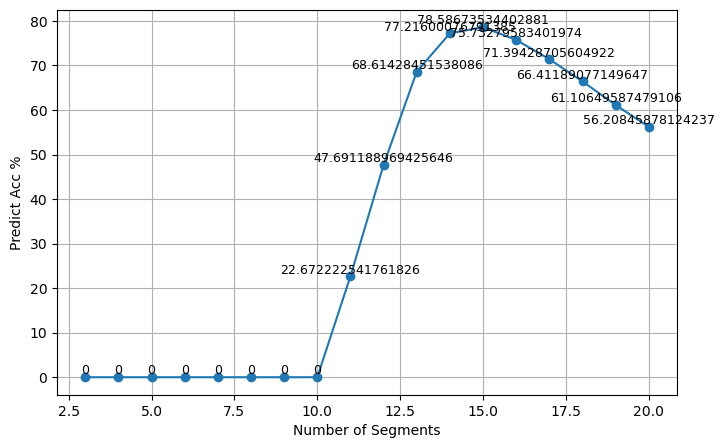

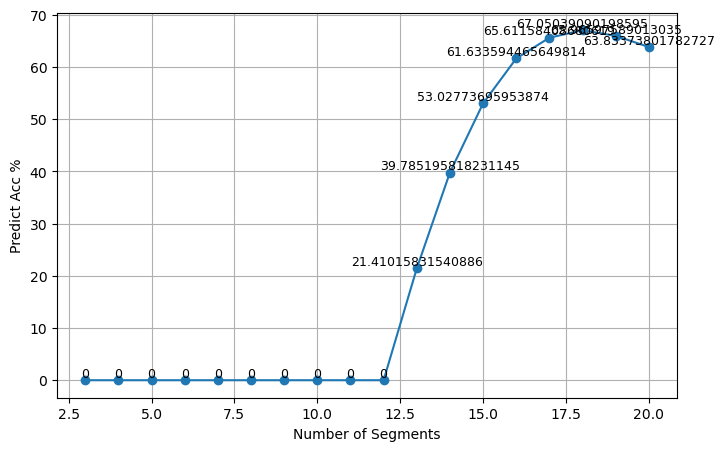

In [ ]:
# checkpoint = "delay_logs/left/Segment-2A1V-NormalGNN/deepGCN/checkpoints/epoch=43-val_loss=3.06.ckpt"
# checkpoint = "delay_logs/left/Segment-2A1V-GraphGPS/5pe/checkpoints/epoch=56-val_loss=2.91.ckpt"
checkpoint = 'delay_logs/left/Segment-2A1V-SGFormer/version_0/checkpoints/epoch=199-val_loss=5.12.ckpt'
# checkpoint = "delay_logs/left/Segment-2A1V-NormalGNN/gat/checkpoints/epoch=58-val_loss=5.51.ckpt"
# checkpoint = "delay_logs/left/Segment-2A1V-NormalGNN/gcn/checkpoints/epoch=58-val_loss=5.10.ckpt"
# checkpoint = "glitch_logs/left/Segment-2A1V-NormalGNN/sage/checkpoints/epoch=17-val_loss=0.02.ckpt"
# checkpoint = "delay_logs/left/Segment-2A1V-NormalGNN/sage/checkpoints/epoch=52-val_loss=5.22.ckpt"
# checkpoint = "delay_logs/left/Segment-2A1V-Graphomer/VanillaGT/checkpoints/epoch=48-val_loss=2.88.ckpt"
acc_seg(model_name, model, checkpoint, 'SGFormer')

In [ ]:
def inference(model_name, model, checkpoint, tag):
    checkpoint = torch.load(checkpoint)
    state_dict = checkpoint['state_dict']
    loaded_model = model
    loaded_model.load_state_dict(state_dict, strict=False)
    loaded_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    loaded_model = loaded_model.to(device)
    if model_name in ['NormGNN', 'DeepGCN']:
        with torch.no_grad():
            for idx, batch in enumerate(test_loader):   
                batch = batch.to(device)
                segment = batch.segment.item()
                if segment == 20:
                    # 2a1v
                    agg1_mask = batch.agg1_mask.bool()
                    agg2_mask = batch.agg2_mask.bool()
                    vic_mask = batch.vic_mask.bool()
                    
                    out = loaded_model(batch.x, batch.edge_index, batch.edge_attr)
                    
                    mask_out1 = out[agg1_mask]
                    mask_label1 = batch.label[agg1_mask]
                    
                    mask_out2 = out[agg2_mask]
                    mask_label2 = batch.label[agg2_mask]
                    
                    mask_out3 = out[vic_mask] 
                    mask_label3 = batch.label[vic_mask]
                    break
                
    elif model_name in ['GraphGPS', 'SGFormer']:
        with torch.no_grad():
            for idx, batch in enumerate(test_loader):   
                batch = batch.to(device)
                segment = batch.segment.item()
                if segment == 20:
                    # 2a1v
                    agg1_mask = batch.agg1_mask.bool()
                    agg2_mask = batch.agg2_mask.bool()
                    vic_mask = batch.vic_mask.bool()
                    out = loaded_model(batch.x, batch.pestat_RWSE, batch.edge_index, batch.edge_attr, batch.batch)
                    
                    mask_out1 = out[agg1_mask]
                    mask_label1 = batch.label[agg1_mask]
                    
                    mask_out2 = out[agg2_mask]
                    mask_label2 = batch.label[agg2_mask]
                    
                    mask_out3 = out[vic_mask] 
                    mask_label3 = batch.label[vic_mask]
                    print(idx)
                    break

    elif model_name == 'Graphomer':
        with torch.no_grad():
            for idx, batch in enumerate(test_loader): 
                (
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    in_degree,
                    out_degree,
                    attn_mask,
                    path_data,
                    dist
                ) = batch
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                in_degree = in_degree.to(device)
                out_degree = out_degree.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                out = loaded_model(
                    node_feat,
                    in_degree,
                    out_degree,
                    path_data,
                    dist,
                    attn_mask=attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_label = node_label.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                if segment == 20 and idx ==125:
                    print(idx, node_label)
                    node_mask[node_mask == -1] = 0
                    node_vic_mask[node_vic_mask == -1] = 0
                    node_agg1_mask[node_agg1_mask == -1] = 0
                    node_agg2_mask[node_agg2_mask == -1] = 0
                    
                    mask = node_mask.bool()
                    agg1_mask = node_agg1_mask.bool()
                    agg2_mask = node_agg2_mask.bool()
                    vic_mask = node_vic_mask.bool()
                    
                    mask_out1 = out[agg1_mask]
                    mask_label1 = node_label[agg1_mask]
                    
                    mask_out2 = out[agg2_mask]
                    mask_label2 = node_label[agg2_mask]
                    
                    mask_out3 = out[vic_mask] 
                    mask_label3 = node_label[vic_mask]
                    break
    else:
        with torch.no_grad():
            for idx, batch in enumerate(test_loader): 
                (
                    bg,
                    bsg,
                    node_feat,
                    node_label,
                    node_mask,
                    node_vic_mask,
                    node_agg1_mask,
                    node_agg2_mask,
                    sink_mask,
                    sink_vic_mask,
                    sink_agg1_mask,
                    sink_agg2_mask,
                    # in_degree,
                    # out_degree,
                    attn_mask,
                    net_token_attn_mask,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A
                ) = batch
                bg = bg.to(device)
                bsg = bsg.to(device)
                node_feat = node_feat.to(device)
                node_label = node_label.to(device)
                node_mask = node_mask.to(device)
                node_vic_mask = node_vic_mask.to(device)
                node_agg1_mask = node_agg1_mask.to(device)
                node_agg2_mask = node_agg2_mask.to(device)
                sink_mask = sink_mask.to(device)
                sink_vic_mask = sink_vic_mask.to(device)
                sink_agg1_mask = sink_agg1_mask.to(device)
                sink_agg2_mask = sink_agg2_mask.to(device)
                attn_mask = attn_mask.to(device)
                net_token_attn_mask = net_token_attn_mask.to(device)
                path_data = path_data.to(device)
                dist = dist.to(device)
                attn_net_A = attn_net_A.to(device)
                attn_couple_A = attn_couple_A.to(device)
                out = loaded_model(
                    bg,
                    bsg,
                    node_feat,
                    # in_degree,
                    # out_degree,
                    path_data,
                    dist,
                    attn_net_A, 
                    attn_couple_A,
                    attn_mask=attn_mask,
                    net_attn_mask = net_token_attn_mask,
                )
                out = out.squeeze(dim=-1)
                node_label = node_label.squeeze(dim=-1)
                node_num = node_feat.shape[1]
                segment = int(node_num/3-1)
                if segment == 20 and idx == 125:
                    print(idx, node_label)
                    node_mask[node_mask == -1] = 0
                    node_vic_mask[node_vic_mask == -1] = 0
                    node_agg1_mask[node_agg1_mask == -1] = 0
                    node_agg2_mask[node_agg2_mask == -1] = 0
                    
                    mask = node_mask.bool()
                    agg1_mask = node_agg1_mask.bool()
                    agg2_mask = node_agg2_mask.bool()
                    vic_mask = node_vic_mask.bool()
                    
                    mask_out1 = out[agg1_mask]
                    mask_label1 = node_label[agg1_mask]
                    
                    mask_out2 = out[agg2_mask]
                    mask_label2 = node_label[agg2_mask]
                    
                    mask_out3 = out[vic_mask] 
                    mask_label3 = node_label[vic_mask]
                    zeromask = mask_label3 != 0
                    zeromask = zeromask.squeeze(-1)
                    masked_out = mask_out3[zeromask]
                    masked_label = mask_label3[zeromask]
                    masked_label = masked_label.squeeze(-1)
                    vict_acc = 100 - (torch.mean(torch.abs(masked_out - masked_label) / torch.abs(masked_label)) * 100)
                    if vict_acc > 95:
                        print(idx, node_label)
                        break
    agg1_pred = mask_out1
    agg1_label = mask_label1
    agg2_pred = mask_out2
    agg2_label = mask_label2
    vic_pred = mask_out3
    vic_label = mask_label3
    root = f"{task}_results/inf_ex/{exp_name}"
    os.makedirs(root, exist_ok=True)
    with open(f'{root}/segment_{tag}_agg1-pred_acc.pkl', 'wb') as f:
        pickle.dump(agg1_pred, f)
    with open(f'{root}/segment_{tag}_agg1-label_acc.pkl', 'wb') as f:
        pickle.dump(agg1_label, f)
    with open(f'{root}/segment_{tag}_agg2-pred_acc.pkl', 'wb') as f:
        pickle.dump(agg2_pred, f)
    with open(f'{root}/segment_{tag}_agg2-label_acc.pkl', 'wb') as f:
        pickle.dump(agg2_label, f)
    with open(f'{root}/segment_{tag}_vic-pred_acc.pkl', 'wb') as f:
        pickle.dump(vic_pred, f)
    with open(f'{root}/segment_{tag}_vic-label_acc.pkl', 'wb') as f:
        pickle.dump(vic_label, f)
   

In [ ]:
checkpoint = "delay_logs/left/Segment-2A1V-GraphGPS/5pe/checkpoints/epoch=56-val_loss=2.91.ckpt"
inference(model_name, model, checkpoint, 'GraphGPS')

/tmp/ipykernel_1477933/2468125348.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint)


64
